In [3]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

from functools import partial

import numpy as onp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl

from msmjax.benchmark_tools import (
    path_input_structures,
    evaluate_structure_with_lammps_p3m,
)
from msmjax.convenience import (
    suggest_msm_params,
    set_up_kernel_fns,
)
from msmjax.shortrange import make_pair_term_fn, make_compute_U0
from msmjax.flexcell import make_flex_cell_U1plus_fn

# Load structure

In [4]:
structures = onp.load(path_input_structures / "structures_1000.npz")

i_structure = 0
pos = structures["positions"][i_structure].astype(onp.float64)
chg = structures["charges"][i_structure].astype(onp.float64)
cell = structures["cells"][i_structure].astype(onp.float64)

box_lengths = onp.diag(cell)
n_structures = len(structures["positions"])
n_particles = pos.shape[0]
avg_particle_spacing = (onp.linalg.det(cell) / n_particles) ** (1 / 3)

# Function definitions

## Energy calculators

In [5]:
calc_energy_ref_nonperiodic = make_pair_term_fn(
    kernel_fn=lambda x: 1.0 / x, pbc=(False, False, False)
)


@jax.jit
def calc_e_and_f_ref_np(positions, charges, cell):
    # TODO: name; move up to where the other function definitions are
    value, grad = jax.value_and_grad(calc_energy_ref_nonperiodic)(
        positions, charges, cell=onp.eye(3)
    )
    return value, -grad


calc_e_and_f_ref_periodic = partial(
    evaluate_structure_with_lammps_p3m,
    lammps_executable="/home/florian/Downloads/lammps-static/bin/lmp",
    max_neighbors_one_atom=10000,
)


def calc_ref_results_set_of_structures(
    set_of_positions, set_of_charges, set_of_cells
):
    energies_ref_nonperiodic, forces_ref_nonperiodic = (
        evaluate_set_of_structures(
            calc_e_and_f_ref_np, set_of_positions, set_of_charges, set_of_cells
        )
    )
    energies_ref_periodic, forces_ref_periodic = evaluate_set_of_structures(
        calc_e_and_f_ref_periodic,
        set_of_positions,
        set_of_charges,
        set_of_cells,
    )
    results = {
        "pbc-False": {
            "energies": energies_ref_nonperiodic,
            "forces": forces_ref_nonperiodic,
        },
        "pbc-True": {
            "energies": energies_ref_periodic,
            "forces": forces_ref_periodic,
        },
    }

    return results

In [7]:
# def set_up_flex_cell_msm_energy_fn(
#     reference_cell, pbc, flex_mode, **msm_params
# ):
#     kernel_fns = set_up_kernel_fns(
#         box_lengths=box_lengths, pbcs=pbc, **msm_params
#     )
#     calc_U0 = make_compute_U0(kernel_fns=kernel_fns, pbc=pbc)
#     calc_U1plus = make_flex_cell_U1plus_fn(
#         kernel_fns=kernel_fns,
#         pbc=pbc,
#         reference_cell=reference_cell,
#         flex_mode=flex_mode,
#         **msm_params,
#     )
#
#     @jax.jit  # TODO: jit here or later?
#     def calc_energy(positions, charges, cell):
#         return calc_U0(positions, charges, cell) + calc_U1plus(
#             positions, charges, cell
#         )
#
#     return calc_energy


def set_up_flex_cell_msm(reference_cell, pbc, flex_mode, **msm_params):
    kernel_fns = set_up_kernel_fns(
        box_lengths=box_lengths, pbcs=pbc, **msm_params
    )
    calc_U0 = make_compute_U0(kernel_fns=kernel_fns, pbc=pbc)
    calc_U1plus = make_flex_cell_U1plus_fn(
        kernel_fns=kernel_fns,
        pbc=pbc,
        reference_cell=reference_cell,
        flex_mode=flex_mode,
        **msm_params,
    )

    def calc_energy(positions, charges, cell):
        return calc_U0(positions, charges, cell) + calc_U1plus(
            positions, charges, cell
        )

    @jax.jit
    def calc_energy_and_forces(positions, charges, cell):
        value, grad = jax.value_and_grad(calc_energy)(positions, charges, cell)
        return value, -grad

    return calc_energy_and_forces

In [22]:
def evaluate_set_of_structures(
    energy_and_forces_fn, set_of_positions, set_of_charges, set_of_cells
):
    energies = onp.full(len(all_positions), onp.nan, dtype=float)
    forces = onp.full_like(onp.asarray(set_of_positions), onp.nan)
    for i, (pos, chg, cell) in enumerate(
        zip(set_of_positions, set_of_charges, set_of_cells)
    ):
        try:
            e, f = energy_and_forces_fn(pos, chg, cell)
            energies[i] = e
            forces[i] = f
        except Exception as exc:
            print(repr(exc))
            continue

    return energies, forces


# @jax.jit
# def calc_e_and_f_ref_np(positions, charges, cell):
#     # TODO: name; move up to where the other function definitions are
#     value, grad = jax.value_and_grad(calc_energy_ref_nonperiodic)(
#         positions, charges, cell=onp.eye(3)
#     )
#     return value, -grad
#
#
# def calc_ref_results_set_of_structures(
#     set_of_positions, set_of_charges, set_of_cells
# ):
#     energies_ref_nonperiodic, forces_ref_nonperiodic = (
#         evaluate_set_of_structures(
#             calc_e_and_f_ref_np, set_of_positions, set_of_charges, set_of_cells
#         )
#     )
#     energies_ref_periodic, forces_ref_periodic = evaluate_set_of_structures(
#         calc_e_and_f_ref_periodic,
#         set_of_positions,
#         set_of_charges,
#         set_of_cells,
#     )
#     results = {
#         "pbc-False": {
#             "energies": energies_ref_nonperiodic,
#             "forces": forces_ref_nonperiodic,
#         },
#         "pbc-True": {
#             "energies": energies_ref_periodic,
#             "forces": forces_ref_periodic,
#         },
#     }
#
#     return results


# TODO: name
def run_and_compare_msm_for_set_of_structures(
    energy_and_forces_fn,
    set_of_positions,
    set_of_charges,
    set_of_cells,
    reference_forces,
):
    energies, forces = evaluate_set_of_structures(
        energy_and_forces_fn, set_of_positions, set_of_charges, set_of_cells
    )
    force_rmses = [
        calc_relative_rmse_percent(y_pred=f, y_true=f_ref)
        for f, f_ref in zip(forces, reference_forces)
    ]

    return {"energies": energies, "forces": forces, "force_rmses": force_rmses}

## Other helper functions

In [8]:
def calc_rmse(y_pred, y_true):
    return onp.sqrt(((y_pred - y_true) ** 2).mean())


def calc_relative_rmse_percent(y_pred, y_true):
    return calc_rmse(y_pred, y_true) / y_true.std() * 100

# Orthogonal: Isotropic strain

In [23]:
lower = 0.5
upper = 2.0
stepsize = 0.05
n_steps = int(onp.round((1.4 - 0.6) / 0.05))
all_deformations = onp.linspace(lower, upper, n_steps)

all_positions = [pos * deformation for deformation in all_deformations]
all_charges = [chg] * len(all_positions)
all_cells = [cell * deformation for deformation in all_deformations]

In [27]:
# TODO: Why is this so slow? Related to the general inefficiency of the current short-range implementation?
test_fn = calc_e_and_f_ref_np

test_fn(pos, chg, cell)[0].block_until_ready()
%timeit test_fn(pos, chg, cell)[1].block_until_ready()

5 ms ± 180 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [25]:
# TODO: Why is this so slow? Related to the general inefficiency of the current short-range implementation?
test_fn = jax.jit(jax.grad(calc_energy_ref_nonperiodic))

test_fn(pos, chg, cell).block_until_ready()
%timeit test_fn(pos, chg, cell).block_until_ready()

8.29 ms ± 288 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
test_fn = jax.jit(calc_energy_ref_nonperiodic)

test_fn(pos, chg, cell).block_until_ready()
%timeit test_fn(pos, chg, cell).block_until_ready()

396 µs ± 164 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Calculate reference

In [30]:
results_ref = calc_ref_results_set_of_structures(
    all_positions, all_charges, all_cells
)

ValueError('EOF reached without finding energy')
ValueError('EOF reached without finding energy')
ValueError('EOF reached without finding energy')
ValueError('EOF reached without finding energy')


# Calculate MSM

In [31]:
FLEX_MODE = "ortho"
R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]

results_msm_flex = {}
for pbc_key, pbc in zip(
    ["pbc-False", "pbc-True"], [(False, False, False), (True, True, True)]
):
    results_msm_flex[pbc_key] = {}
    for spacing in SPACINGS:
        msm_params = suggest_msm_params(
            box_lengths=box_lengths,
            pbcs=pbc,
            n_particles=n_particles,
            level_one_gridspacing=spacing * avg_particle_spacing,
            level_zero_cutoff=R_CUT * avg_particle_spacing,
        )
        calc_e_and_f_msm = set_up_flex_cell_msm(
            reference_cell=cell, pbc=pbc, flex_mode=FLEX_MODE, **msm_params
        )
        actual_spacing = msm_params["level_one_gridspacing"]
        results_msm_flex[pbc_key][actual_spacing] = (
            run_and_compare_msm_for_set_of_structures(
                energy_and_forces_fn=calc_e_and_f_msm,
                set_of_positions=all_positions,
                set_of_charges=all_charges,
                set_of_cells=all_cells,
                reference_forces=results_ref[pbc_key]["forces"],
            )
        )

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Cutoff at highest-but-one level not too large relative to simulation box size ("criterion 2.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")
*) Cutoff at highest-but-one level not too large relative to simulation box size ("criterion 2.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Cutoff at highest-but-one level not too large relative to simulation box size ("criterion 2.")



## Plot

In [32]:
figsize = (8, 5)
plot_titles = {
    "pbc-False": "Non-periodic: flexible-cell MSM vs. reference\n(explicit all-pairs summation)",
    "pbc-True": "Periodic: flexible-cell MSM vs. reference\n(LAMMPS with 'pair_style coul/long 10.0', 'kspace_style pppm 1e-5')",
}

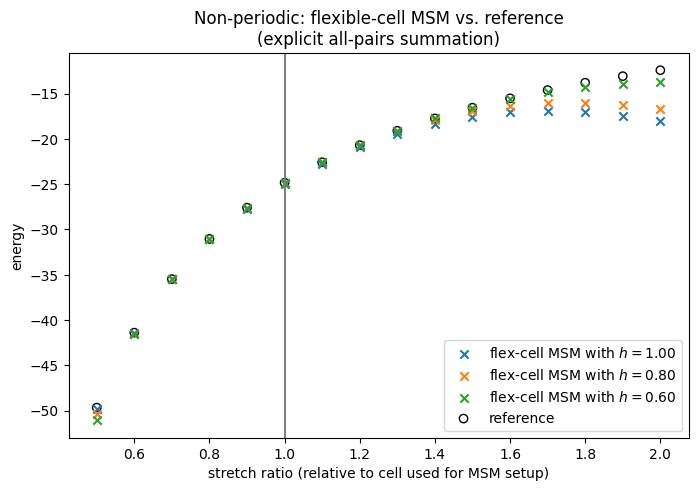

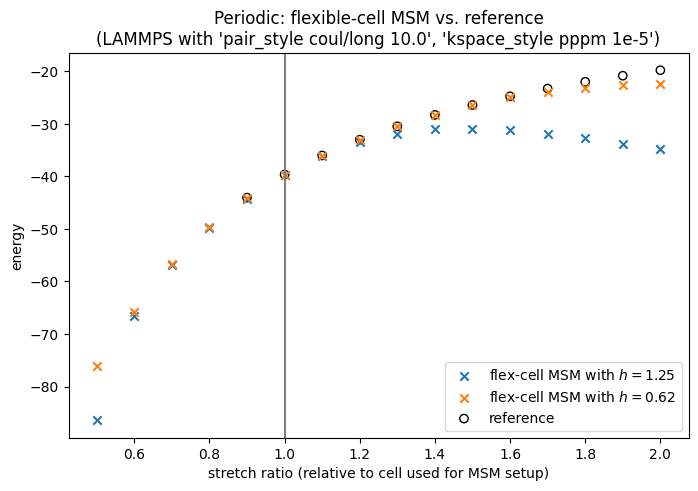

In [33]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(plot_titles[key_pbcs])
    ax.set_xlabel("stretch ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("energy")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["energies"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.scatter(
        all_deformations,
        results_ref[key_pbcs]["energies"],
        color="black",
        facecolor="none",
        label="reference",
        zorder=-10,
    )
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"energies_{key_pbcs}.pdf")
    plt.show()

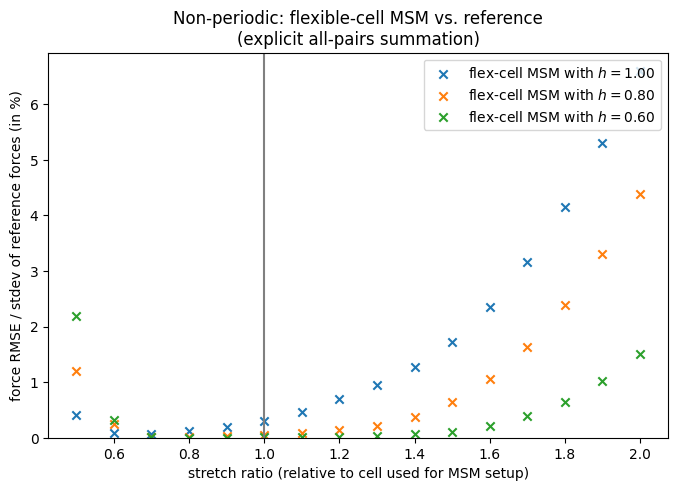

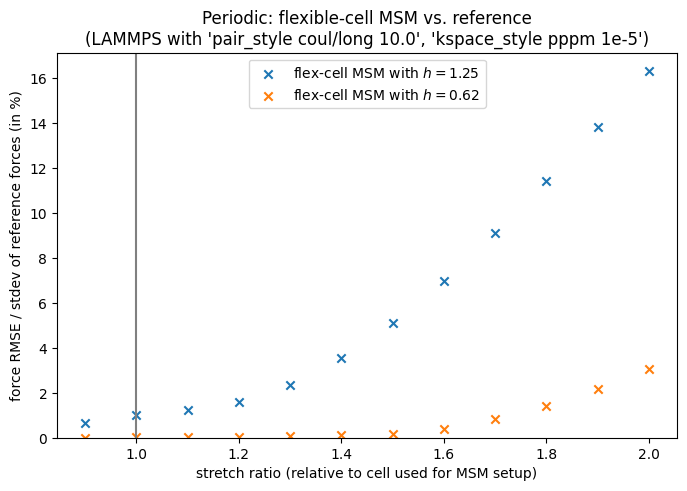

In [34]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(plot_titles[key_pbcs])
    ax.set_xlabel("stretch ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("force RMSE / stdev of reference forces (in %)")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["force_rmses"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.set_ylim([0, ax.get_ylim()[1]])
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"force_rsmes_{key_pbcs}.pdf")
    plt.show()

# Orthogonal: Anisotropic strain

In [ ]:
lower = 0.5
upper = 2.0
stepsize = 0.05
n_steps = int(onp.round((1.4 - 0.6) / 0.05))
all_deformations = onp.linspace(lower, upper, n_steps)

## Calculate reference

In [ ]:
energies_ref_nonperiodic = onp.full_like(all_deformations, onp.nan)
forces_ref_nonperiodic = onp.full(
    (len(all_deformations), n_particles, 3), onp.nan
)
energies_ref_periodic = onp.full_like(energies_ref_nonperiodic, onp.nan)
forces_ref_periodic = onp.full_like(forces_ref_nonperiodic, onp.nan)
for i, deformation in enumerate(all_deformations):
    pos_deformed = pos * [deformation, 1, 1]  # TODO
    cell_deformed = cell * [deformation, 1, 1]  # TODO
    energies_ref_nonperiodic[i] = calc_energy_ref_nonperiodic(
        pos_deformed, chg
    )
    forces_ref_nonperiodic[i] = calc_forces_ref_nonperiodic(pos_deformed, chg)
    try:
        e_ref, f_ref_periodic = calc_e_and_f_ref_periodic(
            pos_deformed, chg, cell_deformed
        )
        energies_ref_periodic[i] = e_ref
        forces_ref_periodic[i] = f_ref_periodic
    except Exception as e:
        print(repr(e))
        continue

results_ref = {
    "pbc-False": {
        "energies": energies_ref_nonperiodic,
        "forces": forces_ref_nonperiodic,
    },
    "pbc-True": {
        "energies": energies_ref_periodic,
        "forces": forces_ref_periodic,
    },
}

## Calculate MSM

In [ ]:
R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]

results_msm_flex = {}
for pbc_key, pbc in zip(
    ["pbc-False", "pbc-True"], [(False, False, False), (True, True, True)]
):
    results_msm_flex[pbc_key] = {}
    for spacing in SPACINGS:
        msm_params = suggest_msm_params(
            box_lengths=box_lengths,
            pbcs=pbc,
            n_particles=n_particles,
            level_one_gridspacing=spacing * avg_particle_spacing,
            level_zero_cutoff=R_CUT * avg_particle_spacing,
        )
        calc_energy_msm = set_up_flex_cell_msm_energy_fn(
            reference_cell=cell, pbc=pbc, **msm_params
        )

        @jax.jit
        def calc_forces_msm(positions, charges, cell):
            return -jax.grad(calc_energy_msm)(positions, charges, cell)

        energies_msm_flex = onp.full_like(all_deformations, onp.nan)
        rmses_msm_flex = onp.full_like(all_deformations, onp.nan)
        for i, deformation in enumerate(all_deformations):
            pos_deformed = pos * [deformation, 1, 1]  # TODO
            cell_deformed = cell * [deformation, 1, 1]  # TODO
            energies_msm_flex[i] = calc_energy_msm(
                pos_deformed, chg, cell_deformed
            )
            f_msm = calc_forces_msm(pos_deformed, chg, cell_deformed)
            rmses_msm_flex[i] = calc_relative_rmse_percent(
                y_pred=f_msm, y_true=results_ref[pbc_key]["forces"][i]
            )

        actual_spacing = msm_params["level_one_gridspacing"]
        results_msm_flex[pbc_key][actual_spacing] = {
            "energies": energies_msm_flex,
            "force_rmses": rmses_msm_flex,
        }

## Plot

In [ ]:
figsize = (8, 5)
plot_titles = {
    "pbc-False": "Non-periodic: flexible-cell MSM vs. reference\n(explicit all-pairs summation)",
    "pbc-True": "Periodic: flexible-cell MSM vs. reference\n(LAMMPS with 'pair_style coul/long 10.0', 'kspace_style pppm 1e-5')",
}

In [ ]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(plot_titles[key_pbcs])
    ax.set_xlabel("stretch ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("energy")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["energies"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.scatter(
        all_deformations,
        results_ref[key_pbcs]["energies"],
        color="black",
        facecolor="none",
        label="reference",
        zorder=-10,
    )
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"energies_{key_pbcs}.pdf")
    plt.show()

In [ ]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(plot_titles[key_pbcs])
    ax.set_xlabel("stretch ratio (relative to cell used for MSM setup)")
    ax.set_ylabel("force RMSE / stdev of reference forces (in %)")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            all_deformations,
            res["force_rmses"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.set_ylim([0, ax.get_ylim()[1]])
    ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"force_rsmes_{key_pbcs}.pdf")
    plt.show()

# General parallelepipeds

In [ ]:
from ase.atoms import Atoms
from ase.visualize import view

## Experiment with deforming structures

In [ ]:
# atoms = Atoms(positions=pos, charges=chg, cell=cell)
# cellpar = atoms.cell.cellpar()

In [ ]:
# gamma = 60
# C_A_RATIO = 1.3

In [ ]:
# cellpar_deformed = cellpar.copy()
# cellpar_deformed[2] *= C_A_RATIO
# cellpar_deformed[5] = gamma
# atoms_deformed = atoms.copy()
# atoms_deformed.set_cell(cellpar_deformed, scale_atoms=True)
# pos_deformed = atoms_deformed.get_positions()
# cell_deformed = atoms_deformed.get_cell()[...]

In [ ]:
# calc_e_and_f_ref_periodic(
#     positions=pos_deformed,
#     charges=chg,
#     cell=cell_deformed,
# )

## Calculate reference

In [ ]:
atoms = Atoms(positions=pos, charges=chg, cell=cell)
cellpar = atoms.cell.cellpar()


def make_deformed_structure(c_a_ratio, gamma):
    cellpar_deformed = cellpar.copy()
    cellpar_deformed[2] *= c_a_ratio
    cellpar_deformed[5] = gamma
    atoms_deformed = atoms.copy()
    atoms_deformed.set_cell(cellpar_deformed, scale_atoms=True)
    pos_deformed = atoms_deformed.get_positions()
    cell_deformed = atoms_deformed.get_cell()[...]

    return pos_deformed, cell_deformed

In [ ]:
C_A_RATIO = 1.0
all_gammas = onp.arange(90, 40, -5).astype(float)

In [ ]:
energies_ref_nonperiodic = onp.full_like(all_gammas, onp.nan)
forces_ref_nonperiodic = onp.full((len(all_gammas), n_particles, 3), onp.nan)
energies_ref_periodic = onp.full_like(energies_ref_nonperiodic, onp.nan)
forces_ref_periodic = onp.full_like(forces_ref_nonperiodic, onp.nan)


for i, gamma in enumerate(all_gammas):  # TODO
    # Build deformed structure
    pos_deformed, cell_deformed = make_deformed_structure(
        gamma=gamma, c_a_ratio=C_A_RATIO
    )

    # Calc nonperiodic reference results
    energies_ref_nonperiodic[i] = calc_energy_ref_nonperiodic(
        pos_deformed, chg
    )
    forces_ref_nonperiodic[i] = calc_forces_ref_nonperiodic(pos_deformed, chg)

    # Calc periodic reference results
    try:
        e_ref, f_ref_periodic = calc_e_and_f_ref_periodic(
            pos_deformed, chg, cell_deformed
        )
        energies_ref_periodic[i] = e_ref
        forces_ref_periodic[i] = f_ref_periodic
    except Exception as e:
        print(repr(e))
        continue

results_ref = {
    "pbc-False": {
        "energies": energies_ref_nonperiodic,
        "forces": forces_ref_nonperiodic,
    },
    "pbc-True": {
        "energies": energies_ref_periodic,
        "forces": forces_ref_periodic,
    },
}

## Calculate MSM

In [ ]:
R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]

results_msm_flex = {}
for pbc_key, pbc in zip(
    ["pbc-False", "pbc-True"], [(False, False, False), (True, True, True)]
):
    results_msm_flex[pbc_key] = {}
    for spacing in SPACINGS:
        msm_params = suggest_msm_params(
            box_lengths=box_lengths,
            pbcs=pbc,
            n_particles=n_particles,
            level_one_gridspacing=spacing * avg_particle_spacing,
            level_zero_cutoff=R_CUT * avg_particle_spacing,
        )
        # TODO: padding?
        # TODO: supercell_diag_required for the deformed cells?
        calc_energy_msm = set_up_flex_cell_msm_energy_fn(
            reference_cell=cell, pbc=pbc, flex_mode="triclinic", **msm_params
        )

        @jax.jit
        def calc_forces_msm(positions, charges, cell):
            return -jax.grad(calc_energy_msm)(positions, charges, cell)

        energies_msm_flex = onp.full_like(all_gammas, onp.nan)
        rmses_msm_flex = onp.full_like(all_gammas, onp.nan)
        for i, gamma in enumerate(all_gammas):  # TODO
            pos_deformed, cell_deformed = make_deformed_structure(
                gamma=gamma, c_a_ratio=C_A_RATIO
            )
            # TODO: generalize `to_unit_cube` for general parallelepipeds
            energies_msm_flex[i] = calc_energy_msm(
                pos_deformed, chg, cell_deformed
            )
            f_msm = calc_forces_msm(pos_deformed, chg, cell_deformed)
            rmses_msm_flex[i] = calc_relative_rmse_percent(
                y_pred=f_msm, y_true=results_ref[pbc_key]["forces"][i]
            )

        actual_spacing = msm_params["level_one_gridspacing"]
        results_msm_flex[pbc_key][actual_spacing] = {
            "energies": energies_msm_flex,
            "force_rmses": rmses_msm_flex,
        }

## Plot

In [ ]:
figsize = (8, 5)
plot_titles = {
    "pbc-False": "Non-periodic: flexible-cell MSM vs. reference\n(explicit all-pairs summation)",
    "pbc-True": "Periodic: flexible-cell MSM vs. reference\n(LAMMPS with 'pair_style coul/long 10.0', 'kspace_style pppm 1e-5')",
}

In [ ]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(plot_titles[key_pbcs])
    # TODO: axis label
    ax.set_xlabel("$\gamma$ / degrees")
    ax.set_ylabel("energy")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            # all_deformations, # TODO
            all_gammas,
            res["energies"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.scatter(
        # all_deformations, # TODO
        all_gammas,
        results_ref[key_pbcs]["energies"],
        color="black",
        facecolor="none",
        label="reference",
        zorder=-10,
    )
    ax.invert_xaxis()
    # ax.axvline(1.0, color="gray")
    ax.legend()
    # fig.savefig(f"energies_{key_pbcs}.pdf")
    plt.show()

In [ ]:
for key_pbcs in ["pbc-False", "pbc-True"]:
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(plot_titles[key_pbcs])
    ax.set_xlabel("$\gamma$ / degrees")
    ax.set_ylabel("force RMSE / stdev of reference forces (in %)")
    for h, res in results_msm_flex[key_pbcs].items():
        ax.scatter(
            # all_deformations,   # TODO
            all_gammas,
            res["force_rmses"],
            label=f"flex-cell MSM with $h={h:.2f}$",
            marker="x",
        )
    ax.set_ylim([0, ax.get_ylim()[1]])
    # ax.axvline(1.0, color="gray")
    ax.invert_xaxis()
    ax.legend()
    # fig.savefig(f"force_rsmes_{key_pbcs}.pdf")
    plt.show()

In [ ]:
view(Atoms(positions=pos_deformed, cell=cell_deformed))

In [ ]:
from msmjax.utils import get_max_cutoff_3d

In [ ]:
get_max_cutoff_3d(cell_deformed)

# Experiment: determine stencils for general parallelepipeds

In [ ]:
import numpy.linalg as la

In [ ]:
CUTOFF = 2.5
# LOWER_STRETCH_LIM = 1.2
STENCIL_PADDING = 1


def get_angle_between_vectors(v1, v2):
    return onp.arccos(onp.dot(v1, v2) / (la.norm(v1) * la.norm(v2)))

In [ ]:
vec_a = onp.array([10, 0])
a = onp.linalg.norm(vec_a)
grid_angle = onp.deg2rad(60)
vec_b = a * onp.array([onp.cos(grid_angle), onp.sin(grid_angle)])

In [ ]:
n_points_a = 11
n_points_b = 15

n_points_along_axes = onp.array([n_points_a, n_points_b])

grid_points_unitcube = onp.stack(
    onp.meshgrid(
        onp.linspace(0, 1, n_points_a),
        onp.linspace(0, 1, n_points_b),
        indexing="ij",
    ),
    axis=-1,
)
grid_points = grid_points_unitcube @ onp.array([vec_a, vec_b])

inds_center = n_points_along_axes // 2
# center = onp.array(
#     [
#         grid_points[n_points_a // 2, n_points_a // 2, 0],
#         grid_points[n_points_b // 2, n_points_b // 2, 1],
#     ]
# )
center = grid_points[inds_center[0], inds_center[1]]

In [ ]:
phis = onp.linspace(0, 2 * onp.pi, 500)
circle_points = (CUTOFF * onp.array([onp.cos(phis), onp.sin(phis)])).T + center

inverse = la.pinv([vec_a, vec_b])

circle_points_transformed = circle_points @ inverse

half_extents = (
    circle_points_transformed.max(axis=0)
    - circle_points_transformed.min(axis=0)
) / 2

# TODO: use correct spacings if periodic
spacings_transformed = 1 / (n_points_along_axes - 1)

# TODO: ceil?
sizes_from_center = onp.floor(half_extents / spacings_transformed).astype(int)
sizes_from_center += onp.asarray(STENCIL_PADDING)

included_inds_along_axes = [
    i + onp.arange(-s, s + 1) for i, s in zip(inds_center, sizes_from_center)
]
included_inds = tuple(
    i.ravel() for i in (onp.meshgrid(*included_inds_along_axes, indexing="ij"))
)

grid_points[included_inds].shape

In [ ]:
grid_points_to_plot = grid_points
center_to_plot = center
circle_points_to_plot = circle_points

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(grid_points_to_plot[..., 0], grid_points_to_plot[..., 1], s=10)
ax.scatter(
    grid_points_to_plot[included_inds][:, 0],
    grid_points_to_plot[included_inds][:, 1],
)
ax.scatter(*center_to_plot, marker="*", s=100)
ax.plot(
    circle_points_to_plot[:, 0], circle_points_to_plot[:, 1], color="black"
)

plt.show()

In [ ]:
grid_points_to_plot = grid_points @ inverse
center_to_plot = center @ inverse
circle_points_to_plot = circle_points @ inverse

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(grid_points_to_plot[..., 0], grid_points_to_plot[..., 1], s=10)
ax.scatter(
    grid_points_to_plot[included_inds][:, 0],
    grid_points_to_plot[included_inds][:, 1],
)
ax.scatter(*center_to_plot, marker="*", s=100)
ax.plot(
    circle_points_to_plot[:, 0], circle_points_to_plot[:, 1], color="black"
)

plt.show()

In [ ]:
spacings = la.norm(onp.array([vec_a, vec_b]), axis=1) / (
    n_points_along_axes - 1
)

In [ ]:
spacings

In [ ]:
inverse @ spacings

In [ ]:
spacings @ inverse

In [ ]:
1 / (n_points_along_axes - 1)

In [ ]:
(vec_a / (n_points_a - 1)) @ inverse

In [ ]:
(vec_b / (n_points_a - 1)) @ inverse

In [ ]:
cell = onp.array([vec_a, vec_b])

In [ ]:
cell / la.norm(cell, axis=1)

In [ ]:
one_grid_cell = cell / la.norm(cell, axis=1) * spacings[:, onp.newaxis]

In [ ]:
onp.diag(one_grid_cell @ inverse)

## With function

In [ ]:
from msmjax.flexcell import determine_kernel_stencil_size

In [ ]:
cell = structures["cells"][0].astype(onp.float64)

In [ ]:
spacing = 1.0
cutoff = 2.5

In [ ]:
determine_kernel_stencil_size(
    cell=cell, spacings=spacing, cutoff=2 * cutoff, padding=[1, 1, 1]
)

In [ ]:
(2 * cutoff) / spacing

In [ ]:
s = 0

In [ ]:
onp.arange(-s, s + 1)

In [ ]:
tuple([157])

In [ ]:
jax.scipy.signal.convolve(onp.arange(4), onp.arange(-2, 3))